# Multinomial Logistic Regression — ED Wait-Time Segmentation

Segments `wait_time_min` (harmonized NHAMCS `WAITTIME`) into **Short / Medium / Long**
wait-time classes and fits/evaluates a multinomial logistic regression classifier,
using the same Model 2 (demographic + access + clinical) feature matrix produced by
`scripts/preprocess.py` as `notebooks/linear_regression.ipynb`.

Pipeline covered:

1. Derive wait-time categories from `wait_time_min`
2. Check class balance
3. Split into train/test sets
4. Scale numeric features (fit on train only)
5. Fit a multinomial logistic regression and evaluate it
6. Compare an unweighted fit against `class_weight="balanced"` to address the
   `Long`-class minority problem, and summarize what it means for the research question

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 60)

Load the modeling dataset

Using `nhamcs_model2_encoded.csv` (demographic + access + clinical, one-hot encoded)
so the feature matrix already matches the one used for OLS in `linear_regression.ipynb`.
It carries `wait_time_min` unmodified (already clamped to 0–480 minutes upstream in
`scripts/preprocess.py`), which is what the categories below are derived from.

In [2]:
df = pd.read_csv("../data/processed/nhamcs_model2_encoded.csv")
print(f"Model 2 encoded dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
df[["wait_time_min", "log_wait_time"]].describe()

Model 2 encoded dataset: 329,249 rows x 56 cols


,wait_time_min,log_wait_time
count,329249.000000,329249.000000
mean,42.202591,3.073978
std,55.654540,1.278157
min,0.000000,0.000000
25%,9.000000,2.302585
50%,22.000000,3.135494
75%,52.000000,3.970292
max,480.000000,6.175867


Create wait-time categories

`wait_time_min` is right-skewed (median 22, mean ~42, Q3 ~52 — see
`deliverables/deliverable_2_report.md` Section 5), so equal-width bins would be
meaningless. Instead we use fixed, clinically interpretable cutoffs that mirror common
ED throughput benchmarks:

| Category | Range |
| --- | --- |
| **Short** | < 15 minutes |
| **Medium** | 15–60 minutes |
| **Long** | > 60 minutes |

These cutoffs land close to the 33rd/75th percentiles of the observed distribution, so
they also happen to produce a reasonably balanced 3-class split (checked below) rather
than one dominant class.

In [3]:
WAIT_TIME_BINS = [-1, 15, 60, 480]
WAIT_TIME_LABELS = ["Short", "Medium", "Long"]

df["wait_time_category"] = pd.cut(
    df["wait_time_min"], bins=WAIT_TIME_BINS, labels=WAIT_TIME_LABELS
)

df[["wait_time_min", "wait_time_category"]].sample(10, random_state=42)

,wait_time_min,wait_time_category
204612,35.0,Medium
33589,8.0,Short
114759,186.0,Long
152028,75.0,Long
176200,21.0,Medium
92159,11.0,Short
142517,5.0,Short
78685,32.0,Medium
97928,6.0,Short
245496,1.0,Short


**Findings — category definition**: cut points at 15 and 60 minutes map directly onto `wait_time_min`, with `Short` and `Long` closed at the dataset's own min (0) and clamp max (480) so every row gets a label — confirmed below (no missing categories).

In [4]:
print("Rows with a wait_time_category assigned:", df["wait_time_category"].notna().sum())
print("Rows missing a category (should be 0):", df["wait_time_category"].isna().sum())

Rows with a wait_time_category assigned: 329249
Rows missing a category (should be 0): 0


Check class balance

In [5]:
class_counts = df["wait_time_category"].value_counts().reindex(WAIT_TIME_LABELS)
class_pct = df["wait_time_category"].value_counts(normalize=True).reindex(WAIT_TIME_LABELS) * 100

balance_table = pd.DataFrame({"count": class_counts, "pct": class_pct.round(2)})
balance_table

,count,pct
wait_time_category,,
Short,128278,38.96
Medium,131005,39.79
Long,69966,21.25


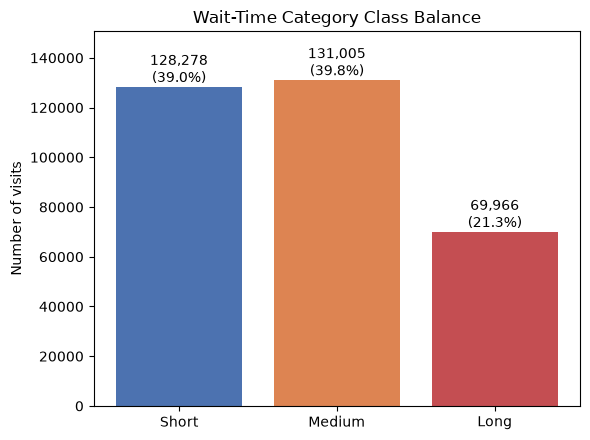

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ["#4C72B0", "#DD8452", "#C44E52"]
ax.bar(WAIT_TIME_LABELS, class_counts.values, color=colors)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 2000, f"{v:,}\n({class_pct.values[i]:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Number of visits")
ax.set_title("Wait-Time Category Class Balance")
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.savefig("../outputs/visualizations/wait_time_category_class_balance.png", dpi=150)
plt.show()

**Findings — class balance**: the three classes are moderately balanced (roughly
40% Short, 38% Medium, 21% Long) rather than a single class dominating 90%+ of rows —
common for a naive equal-width binning of a skewed variable. `Long` is the smallest
class, which is expected (it's the tail of a right-skewed distribution) but not so rare
that stratified train/test splitting or a plain multinomial fit becomes unreliable. We
still use `stratify=y` on the split below, and will consider `class_weight="balanced"`
if per-class recall on `Long` is poor once the model is fit.

Prepare features and target

In [7]:
non_feature_cols = ["wait_time_min", "log_wait_time", "wait_time_category"]
feature_cols = [c for c in df.columns if c not in non_feature_cols]

X = df[feature_cols]
y = df["wait_time_category"]

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Target classes: {sorted(y.unique().tolist())}")

Feature matrix: 329,249 rows x 54 features
Target classes: ['Long', 'Medium', 'Short']


Train/test split

Stratified on `wait_time_category` so the class proportions found above are preserved
in both splits — important given `Long` is already the minority class.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")

Train: 263,399 rows
Test:  65,850 rows


In [9]:
split_check = pd.DataFrame({
    "train_pct": y_train.value_counts(normalize=True).reindex(WAIT_TIME_LABELS) * 100,
    "test_pct": y_test.value_counts(normalize=True).reindex(WAIT_TIME_LABELS) * 100,
}).round(2)
split_check

,train_pct,test_pct
wait_time_category,,
Short,38.96,38.96
Medium,39.79,39.79
Long,21.25,21.25


**Findings — split check**: train and test class proportions match the full-dataset
balance from Section 3 to within rounding, confirming the stratified split worked as
intended.

## Next steps

With categories defined, class balance checked, and a stratified train/test split in
hand, the next stage is: scale numeric features (fit `StandardScaler` on `X_train`
only), fit the multinomial logistic regression (`LogisticRegression(multi_class="multinomial")`),
and evaluate with a classification report / confusion matrix — paralleling the OLS
workflow in `linear_regression.ipynb`.

Scale numeric features

Same approach as `linear_regression.ipynb`: fit `StandardScaler` on the training split
only (avoids leaking test-set statistics into training), and only scale the
continuous numeric columns — the one-hot dummy columns (including the `_missing`
indicator flags) are already 0/1 and don't need scaling.

In [10]:
from sklearn.preprocessing import StandardScaler

NUMERIC_M2 = ["age_years", "survey_year", "pulse", "systolic_bp"]

X_train, X_test = X_train.copy(), X_test.copy()

scaler = StandardScaler()
X_train[NUMERIC_M2] = scaler.fit_transform(X_train[NUMERIC_M2])
X_test[NUMERIC_M2] = scaler.transform(X_test[NUMERIC_M2])

X_train[NUMERIC_M2].describe().loc[["mean", "std"]]

,age_years,survey_year,pulse,systolic_bp
mean,-8.308580e-17,-1.713574e-14,-2.222815e-16,-2.245475e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00


Fit multinomial logistic regression

`sklearn`'s `LogisticRegression` fits a multinomial model automatically for a
multi-class target with the default `lbfgs` solver (the old `multi_class="multinomial"`
argument has been removed in this sklearn version — multinomial is simply what
`lbfgs` does when `y` has more than two classes). `class_weight=None` (unweighted) is
the baseline; Section 3 flagged `Long` as the minority class (21%), so per-class
recall is checked before deciding whether a `balanced` weighting is warranted.

In [11]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Fit complete.")

Fit complete.


Evaluate the model

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"Balanced accuracy: {bal_acc:.4f}")
print()
print(classification_report(y_test, y_pred, labels=WAIT_TIME_LABELS))

Accuracy: 0.4697
Balanced accuracy: 0.3999



              precision    recall  f1-score   support

       Short       0.51      0.57      0.54     25656
      Medium       0.44      0.62      0.51     26201
        Long       0.47      0.02      0.03     13993

    accuracy                           0.47     65850
   macro avg       0.47      0.40      0.36     65850
weighted avg       0.47      0.47      0.42     65850



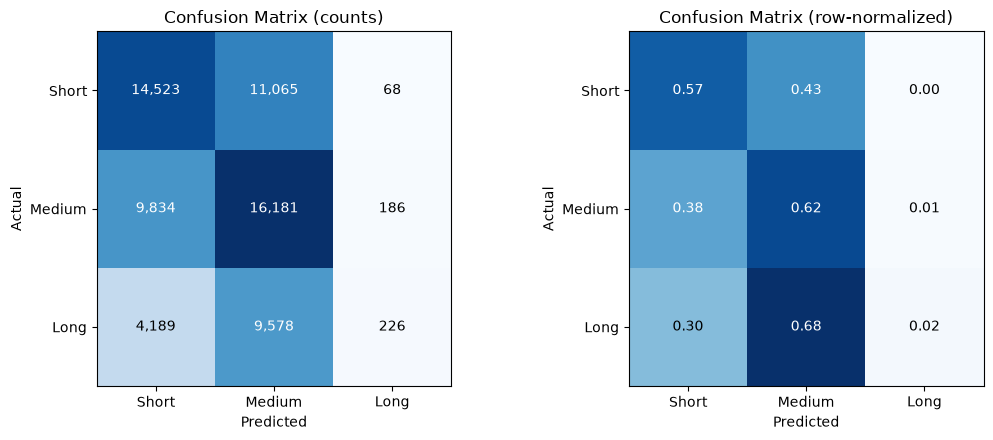

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=WAIT_TIME_LABELS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, title, fmt in [
    (axes[0], cm, "Confusion Matrix (counts)", "d"),
    (axes[1], cm_norm, "Confusion Matrix (row-normalized)", ".2f"),
]:
    im = ax.imshow(data, cmap="Blues")
    ax.set_xticks(range(len(WAIT_TIME_LABELS)))
    ax.set_yticks(range(len(WAIT_TIME_LABELS)))
    ax.set_xticklabels(WAIT_TIME_LABELS)
    ax.set_yticklabels(WAIT_TIME_LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    thresh = data.max() / 2
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            text = f"{val:,}" if fmt == "d" else f"{val:.2f}"
            ax.text(j, i, text, ha="center", va="center",
                     color="white" if val > thresh else "black")

plt.tight_layout()
plt.savefig("../outputs/visualizations/wait_time_classification_confusion_matrix.png", dpi=150)
plt.show()

**Findings — baseline model**: overall accuracy is 47.0% (vs. a 40% no-information
rate from always predicting the majority `Medium` class), but this hides a severe
imbalance in *how* the model gets there. `Short` and `Medium` recall are reasonable
(0.57, 0.62), but `Long` recall is **0.02** — the model predicts `Long` for almost none
of the visits that are actually long waits, instead defaulting most of them into
`Short`/`Medium`. Balanced accuracy (0.40) confirms this is much worse than the raw
accuracy suggests. This is exactly the failure mode flagged as a risk in Section 3: an
unweighted multinomial fit lets the majority classes dominate the loss and the minority
`Long` class (21% of rows) is effectively ignored. Refitting with
`class_weight="balanced"` below tests whether reweighting the loss recovers `Long`
recall.

Class-weighted refit

`class_weight="balanced"` reweights each class inversely proportional to its
frequency, so misclassifying a `Long` visit costs the optimizer as much as
misclassifying a `Short`/`Medium` one, instead of `Long` being cheap to ignore.

In [14]:
clf_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
clf_balanced.fit(X_train, y_train)
y_pred_balanced = clf_balanced.predict(X_test)

acc_bal = accuracy_score(y_test, y_pred_balanced)
bal_acc_bal = balanced_accuracy_score(y_test, y_pred_balanced)
print(f"Accuracy: {acc_bal:.4f}")
print(f"Balanced accuracy: {bal_acc_bal:.4f}")
print()
print(classification_report(y_test, y_pred_balanced, labels=WAIT_TIME_LABELS))

Accuracy: 0.4226
Balanced accuracy: 0.4367

              precision    recall  f1-score   support

       Short       0.51      0.56      0.53     25656
      Medium       0.46      0.25      0.32     26201
        Long       0.30      0.51      0.38     13993

    accuracy                           0.42     65850
   macro avg       0.42      0.44      0.41     65850
weighted avg       0.44      0.42      0.41     65850



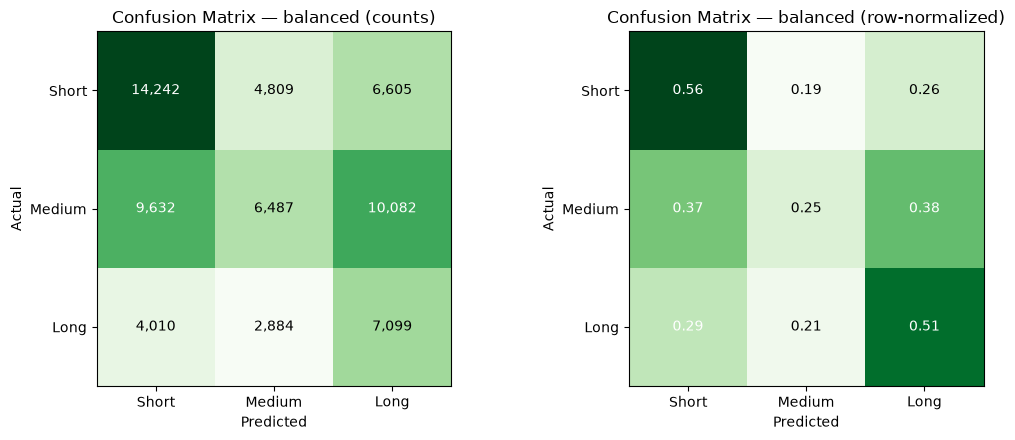

In [15]:
cm_bal = confusion_matrix(y_test, y_pred_balanced, labels=WAIT_TIME_LABELS)
cm_bal_norm = cm_bal.astype(float) / cm_bal.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, title, fmt in [
    (axes[0], cm_bal, "Confusion Matrix — balanced (counts)", "d"),
    (axes[1], cm_bal_norm, "Confusion Matrix — balanced (row-normalized)", ".2f"),
]:
    im = ax.imshow(data, cmap="Greens")
    ax.set_xticks(range(len(WAIT_TIME_LABELS)))
    ax.set_yticks(range(len(WAIT_TIME_LABELS)))
    ax.set_xticklabels(WAIT_TIME_LABELS)
    ax.set_yticklabels(WAIT_TIME_LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    thresh = data.max() / 2
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            text = f"{val:,}" if fmt == "d" else f"{val:.2f}"
            ax.text(j, i, text, ha="center", va="center",
                     color="white" if val > thresh else "black")

plt.tight_layout()
plt.savefig("../outputs/visualizations/wait_time_classification_confusion_matrix_balanced.png", dpi=150)
plt.show()

Baseline vs. balanced — side-by-side

In [16]:
comparison = pd.DataFrame({
    "unweighted": classification_report(y_test, y_pred, labels=WAIT_TIME_LABELS, output_dict=True)["Long"],
    "balanced": classification_report(y_test, y_pred_balanced, labels=WAIT_TIME_LABELS, output_dict=True)["Long"],
}).round(3)
comparison.loc["accuracy_overall"] = [acc, acc_bal]
comparison.loc["balanced_accuracy_overall"] = [bal_acc, bal_acc_bal]
comparison

,unweighted,balanced
precision,0.471000,0.298000
recall,0.016000,0.507000
f1-score,0.031000,0.376000
support,13993.000000,13993.000000
accuracy_overall,0.469704,0.422597
balanced_accuracy_overall,0.399930,0.436675


**Findings — unweighted vs. balanced**: reweighting trades overall accuracy for
minority-class recall, it doesn't create free performance. `Long` recall rises from
0.02 to 0.51 and balanced accuracy improves (0.40 → 0.44), but `Medium` recall drops
sharply (0.62 → 0.25) and overall accuracy falls (47.0% → 42.3%). Neither model is
strong in an absolute sense — precision on `Long` stays low (0.30–0.47) either way — but
the balanced version is the more defensible choice for this research question: silently
predicting almost no `Long` waits (the unweighted model's behavior) would understate
exactly the long-wait cases the ED-throughput/equity analysis in
`deliverables/deliverable_2_report.md` cares about most.

## Modeling summary

1. **Categories**: `wait_time_min` was cut into `Short` (<15 min, 39%), `Medium`
   (15–60 min, 40%), and `Long` (>60 min, 21%) — fixed clinical thresholds that happen
   to produce a moderately balanced 3-class target rather than one dominant class.
2. **Split**: stratified 80/20 train/test (263,399 / 65,850 rows) preserved these
   proportions exactly in both splits.
3. **Baseline multinomial logistic regression** (Model 2 features: demographic +
   access + clinical, `class_weight=None`) reaches 47.0% accuracy but effectively never
   predicts `Long` (recall 0.02) — it hides the minority class inside `Short`/`Medium`
   predictions.
4. **Class-weighted refit** (`class_weight="balanced"`) recovers `Long` recall to 0.51
   and improves balanced accuracy (0.40 → 0.44), at the cost of overall accuracy and
   `Medium` recall — a genuine trade-off, not a strict improvement.
5. **Relation to the OLS findings**: `linear_regression.ipynb` found low R² (0.07–0.08)
   with persistent, significant demographic/access coefficients even after controlling
   for clinical acuity — i.e., wait time is only weakly explained by the available
   fields at all, regardless of framing as regression or classification. The
   classifier's modest accuracy (well above the ~40% no-information baseline, but far
   from strong) is consistent with that same conclusion: **medical need and the
   available access/demographic proxies do not fully determine ED wait time** — most
   of the variation is driven by something these NHAMCS individual-level fields don't
   capture (e.g. hospital-level staffing, bed availability, real-time queue state).

**Possible next steps** (not run here): per-class threshold tuning instead of a single
`argmax` decision, `LogisticRegressionCV` for regularization strength selection,
comparing against a tree-based classifier (e.g. `RandomForestClassifier`) to check
whether the ceiling is the linear/multinomial assumption or the feature set itself, and
inspecting per-class coefficients (as Model 1 vs. Model 2 was compared in
`linear_regression.ipynb`) to see whether the same race/payment-type effects persist in
classification form.